In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [20]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

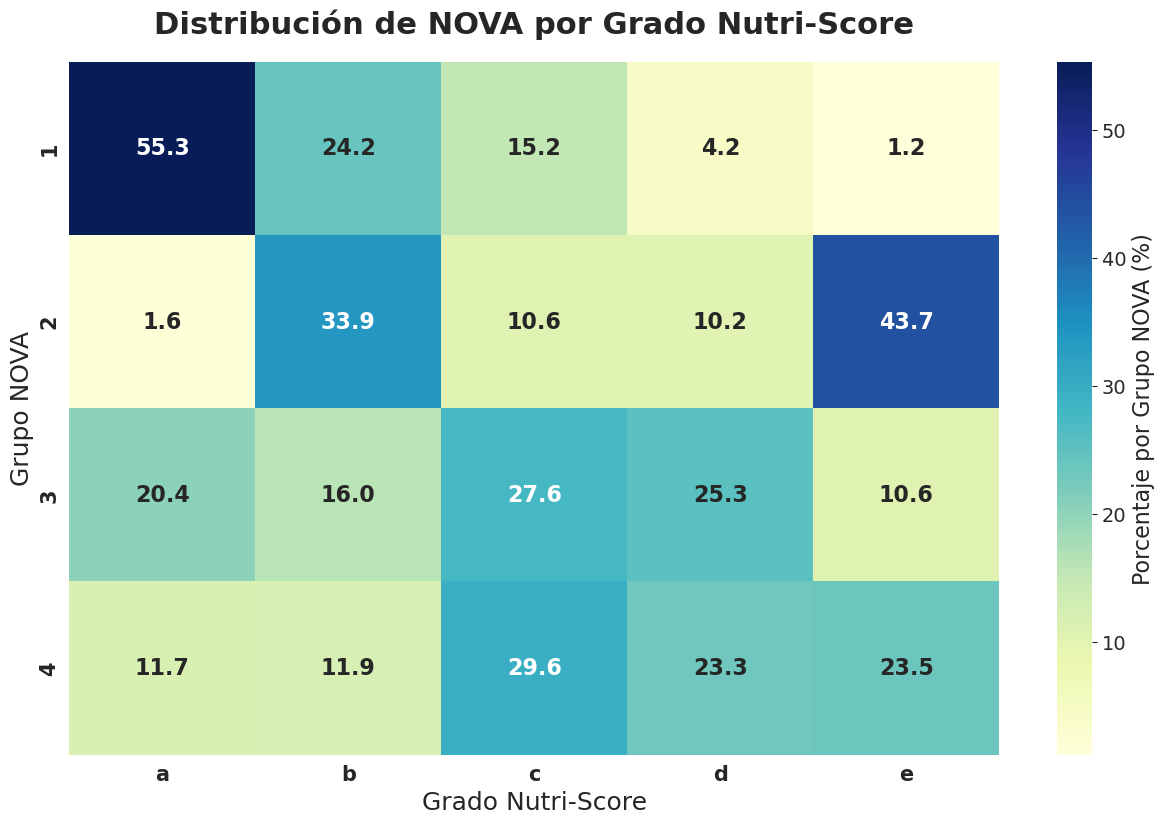

In [21]:

# 1. Filtrado de datos 
df_paradox = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'] > 0)
].copy()

# 2. Generación de la tabla 
cross_tab = pd.crosstab(
    df_paradox['nova_group'], 
    df_paradox['nutriscore_grade'], 
    normalize='index'
) * 100
cross_tab = cross_tab.reindex(columns=['a', 'b', 'c', 'd', 'e'])

# 4. Configuración y visualización con fuentes aumentadas
plt.figure(figsize=(15, 9))

# Guardamos el heatmap en una variable 'ax' para acceder a sus propiedades
ax = sns.heatmap(
    cross_tab, 
    annot=True, 
    annot_kws={"size": 16, "weight": "bold"}, 
    cmap="YlGnBu", 
    fmt=".1f", 
    cbar_kws={'label': 'Porcentaje por Grupo NOVA (%)'}
)

# Títulos de los ejes
plt.title("Distribución de NOVA por Grado Nutri-Score", fontsize=22, fontweight='bold', pad=20)
plt.ylabel("Grupo NOVA", fontsize=18)
plt.xlabel("Grado Nutri-Score", fontsize=18)

# Números de los ejes (Ticks)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# Ajuste de la leyenda (Colorbar)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14) # Números de la leyenda
cbar.set_label('Porcentaje por Grupo NOVA (%)', size=16) # Título de la leyenda

# Guardad gráfico
plt.savefig('../images/01_h01/1.1_heatmap.png', bbox_inches='tight', dpi=300)

plt.show()

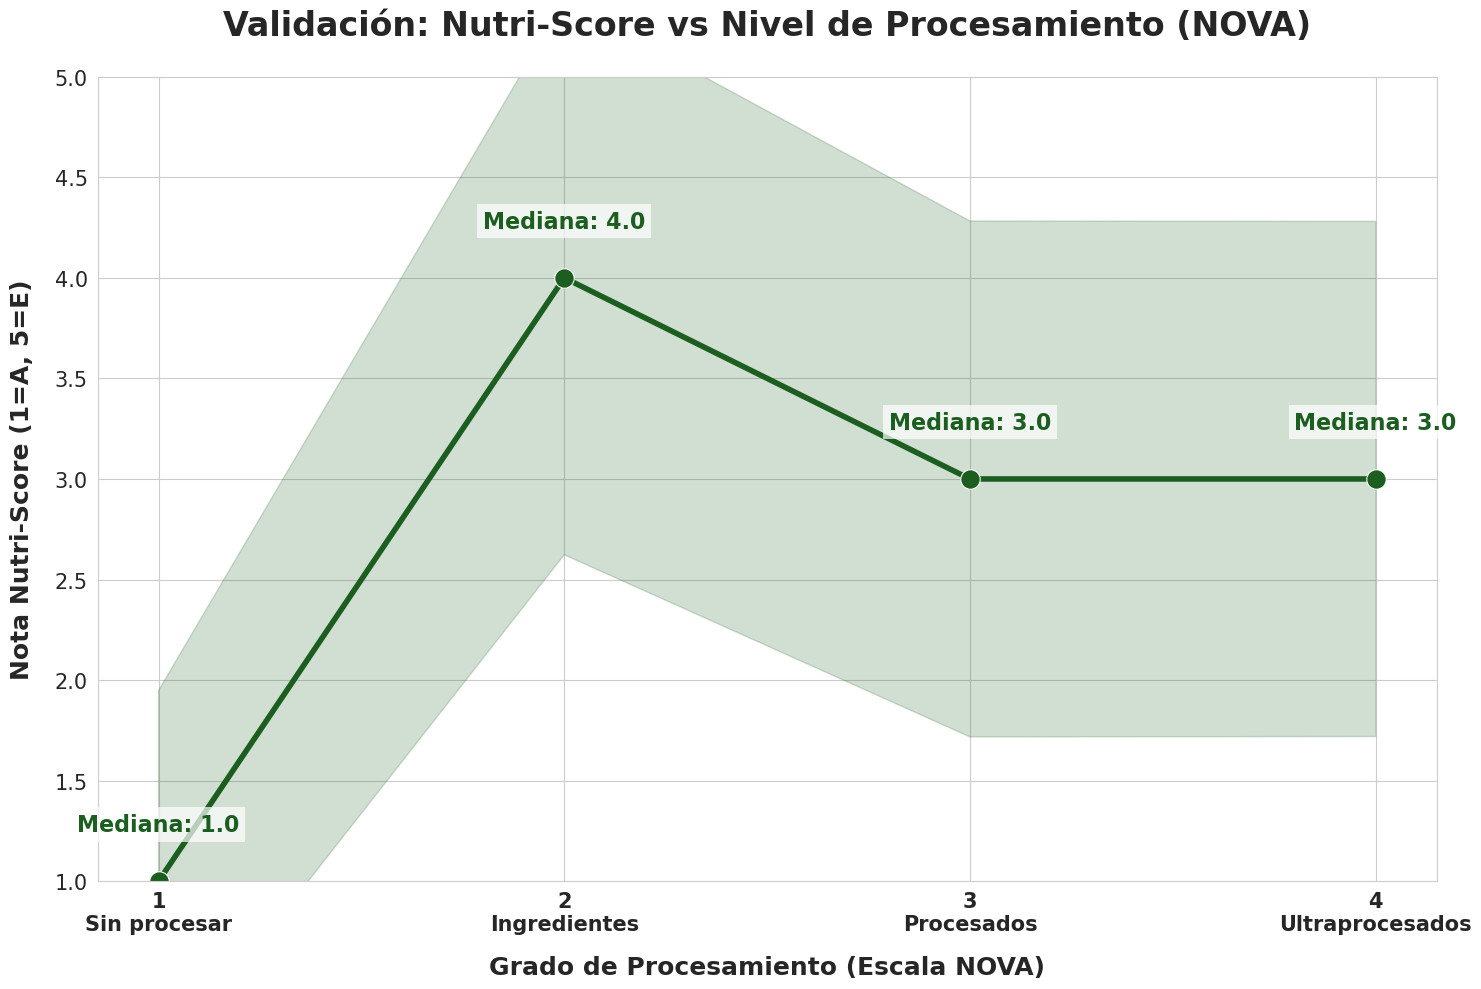

In [22]:
# --- 1. PREPARACIÓN DE DATOS ---
df_val = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'].isin([1, 2, 3, 4]))
].copy()

# Escala: 1 es A (Mejor), 5 es E (Peor)
df_val['nutri_numeric'] = df_val['nutriscore_grade'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5})

# Cálculo de estadísticas para las etiquetas
resumen_nova = df_val.groupby('nova_group')['nutri_numeric'].median().reset_index()

# --- 2. VISUALIZACIÓN DE TENDENCIA ---
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

# Gráfico de línea con desviación estándar (errorbar)
ax = sns.lineplot(
    data=df_val, 
    x='nova_group', 
    y='nutri_numeric', 
    estimator='median', 
    marker='o', 
    markersize=14,      # Puntos más grandes
    color='#1b5e20',    # Verde oscuro profesional
    linewidth=4,        # Línea más gruesa
    errorbar='sd'       # Muestra la dispersión (desviación estándar)
)

# --- 3. ESTÉTICA Y FUENTES ---
plt.title("Validación: Nutri-Score vs Nivel de Procesamiento (NOVA)", 
          fontsize=24, fontweight='bold', pad=30)

plt.xlabel("Grado de Procesamiento (Escala NOVA)", fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel("Nota Nutri-Score (1=A, 5=E)", fontsize=18, fontweight='bold', labelpad=15)

# Etiquetas del eje X más descriptivas y grandes
plt.xticks(
    ticks=[1, 2, 3, 4], 
    labels=['1\nSin procesar', '2\nIngredientes', '3\nProcesados', '4\nUltraprocesados'],
    fontsize=15, 
    fontweight='bold'
)
plt.yticks(fontsize=15)
plt.ylim(1, 5) 

# --- 4. ETIQUETAS DE VALOR (DATA LABELS) ---
for x, y in zip(resumen_nova['nova_group'], resumen_nova['nutri_numeric']):
    plt.text(
        x, y + 0.25, 
        f"Mediana: {y:.1f}", 
        ha='center', 
        fontweight='bold', 
        color='#1b5e20', 
        fontsize=16,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') # Fondo para legibilidad
    )

plt.tight_layout()

# --- 5. GUARDAR ---
plt.savefig('../images/01_h01/1.2_validacion_nova.png', bbox_inches='tight', dpi=300)
plt.show()

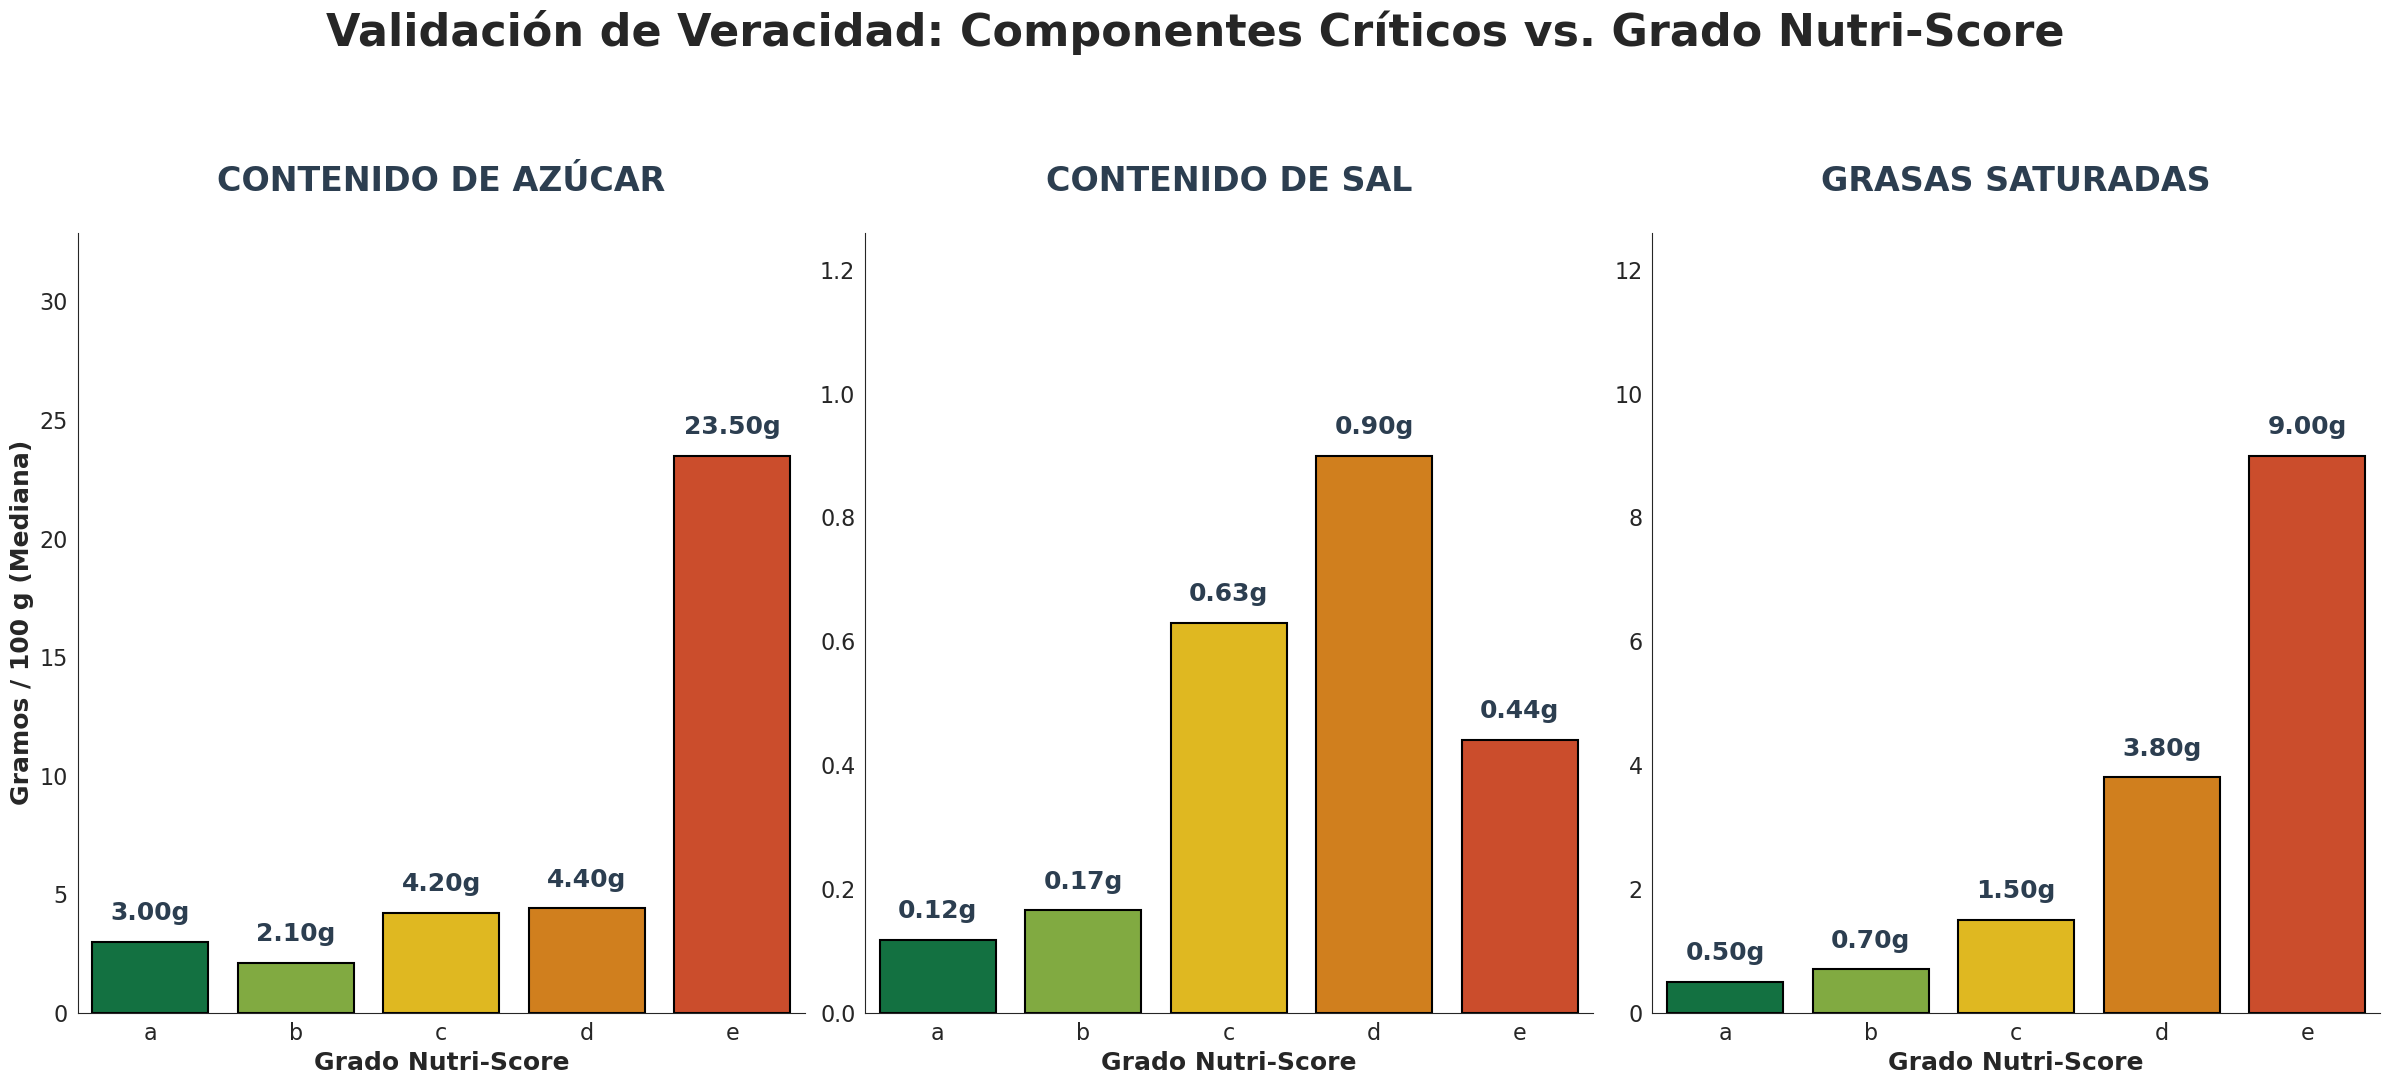

In [23]:
# 1. Preparación de datos
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
titulos = ['CONTENIDO DE AZÚCAR', 'CONTENIDO DE SAL', 'GRASAS SATURADAS']
unidades = ['g', 'g', 'g']

# Agrupamos por mediana
medianas = df_veracidad.groupby('nutriscore_grade')[nutrientes].median().reset_index()

# 2. Configuración estética
sns.set_style("white") # Fondo blanco puro para que resalten los colores
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}
order = ['a', 'b', 'c', 'd', 'e']

# 3. Generación de subplots
for i, nutriente in enumerate(nutrientes):
    ax = axes[i]
    
    sns.barplot(
        ax=ax, 
        x='nutriscore_grade', 
        y=nutriente, 
        data=medianas, 
        order=order, 
        palette=nutri_palette, 
        hue='nutriscore_grade', 
        legend=False,
        edgecolor='black',    # Borde negro para definición
        linewidth=1.5
    )
    
    # Anotaciones con 2 decimales y fuente grande
    for p in ax.patches:
        val = p.get_height()
        if not pd.isna(val):
            ax.annotate(f'{val:.2f}{unidades[i]}', 
                        (p.get_x() + p.get_width() / 2., val), 
                        ha='center', va='bottom', 
                        xytext=(0, 12), 
                        textcoords='offset points', 
                        fontsize=18,      # Fuente muy legible
                        fontweight='bold', 
                        color='#2c3e50')

    # Títulos y etiquetas (Maximizadas)
    ax.set_title(titulos[i], fontsize=24, pad=30, fontweight='bold', color='#2c3e50')
    ax.set_ylabel("Gramos / 100 g (Mediana)" if i==0 else "", fontsize=18, fontweight='bold')
    ax.set_xlabel("Grado Nutri-Score", fontsize=18, fontweight='bold')
    
    # Números de los ejes
    ax.tick_params(axis='both', labelsize=16)
    
    # Ajuste de escala para que las anotaciones no choquen con el techo
    ax.set_ylim(0, medianas[nutriente].max() * 1.4)
    sns.despine(ax=ax)

# Título general imponente
plt.suptitle("Validación de Veracidad: Componentes Críticos vs. Grado Nutri-Score", 
             fontsize=32, fontweight='bold', y=1.08)

plt.tight_layout()

# --- 4. GUARDAR ---
plt.savefig('../images/01_h01/1.3_veracidad_nutrientes.png', bbox_inches='tight', dpi=300)
plt.show()

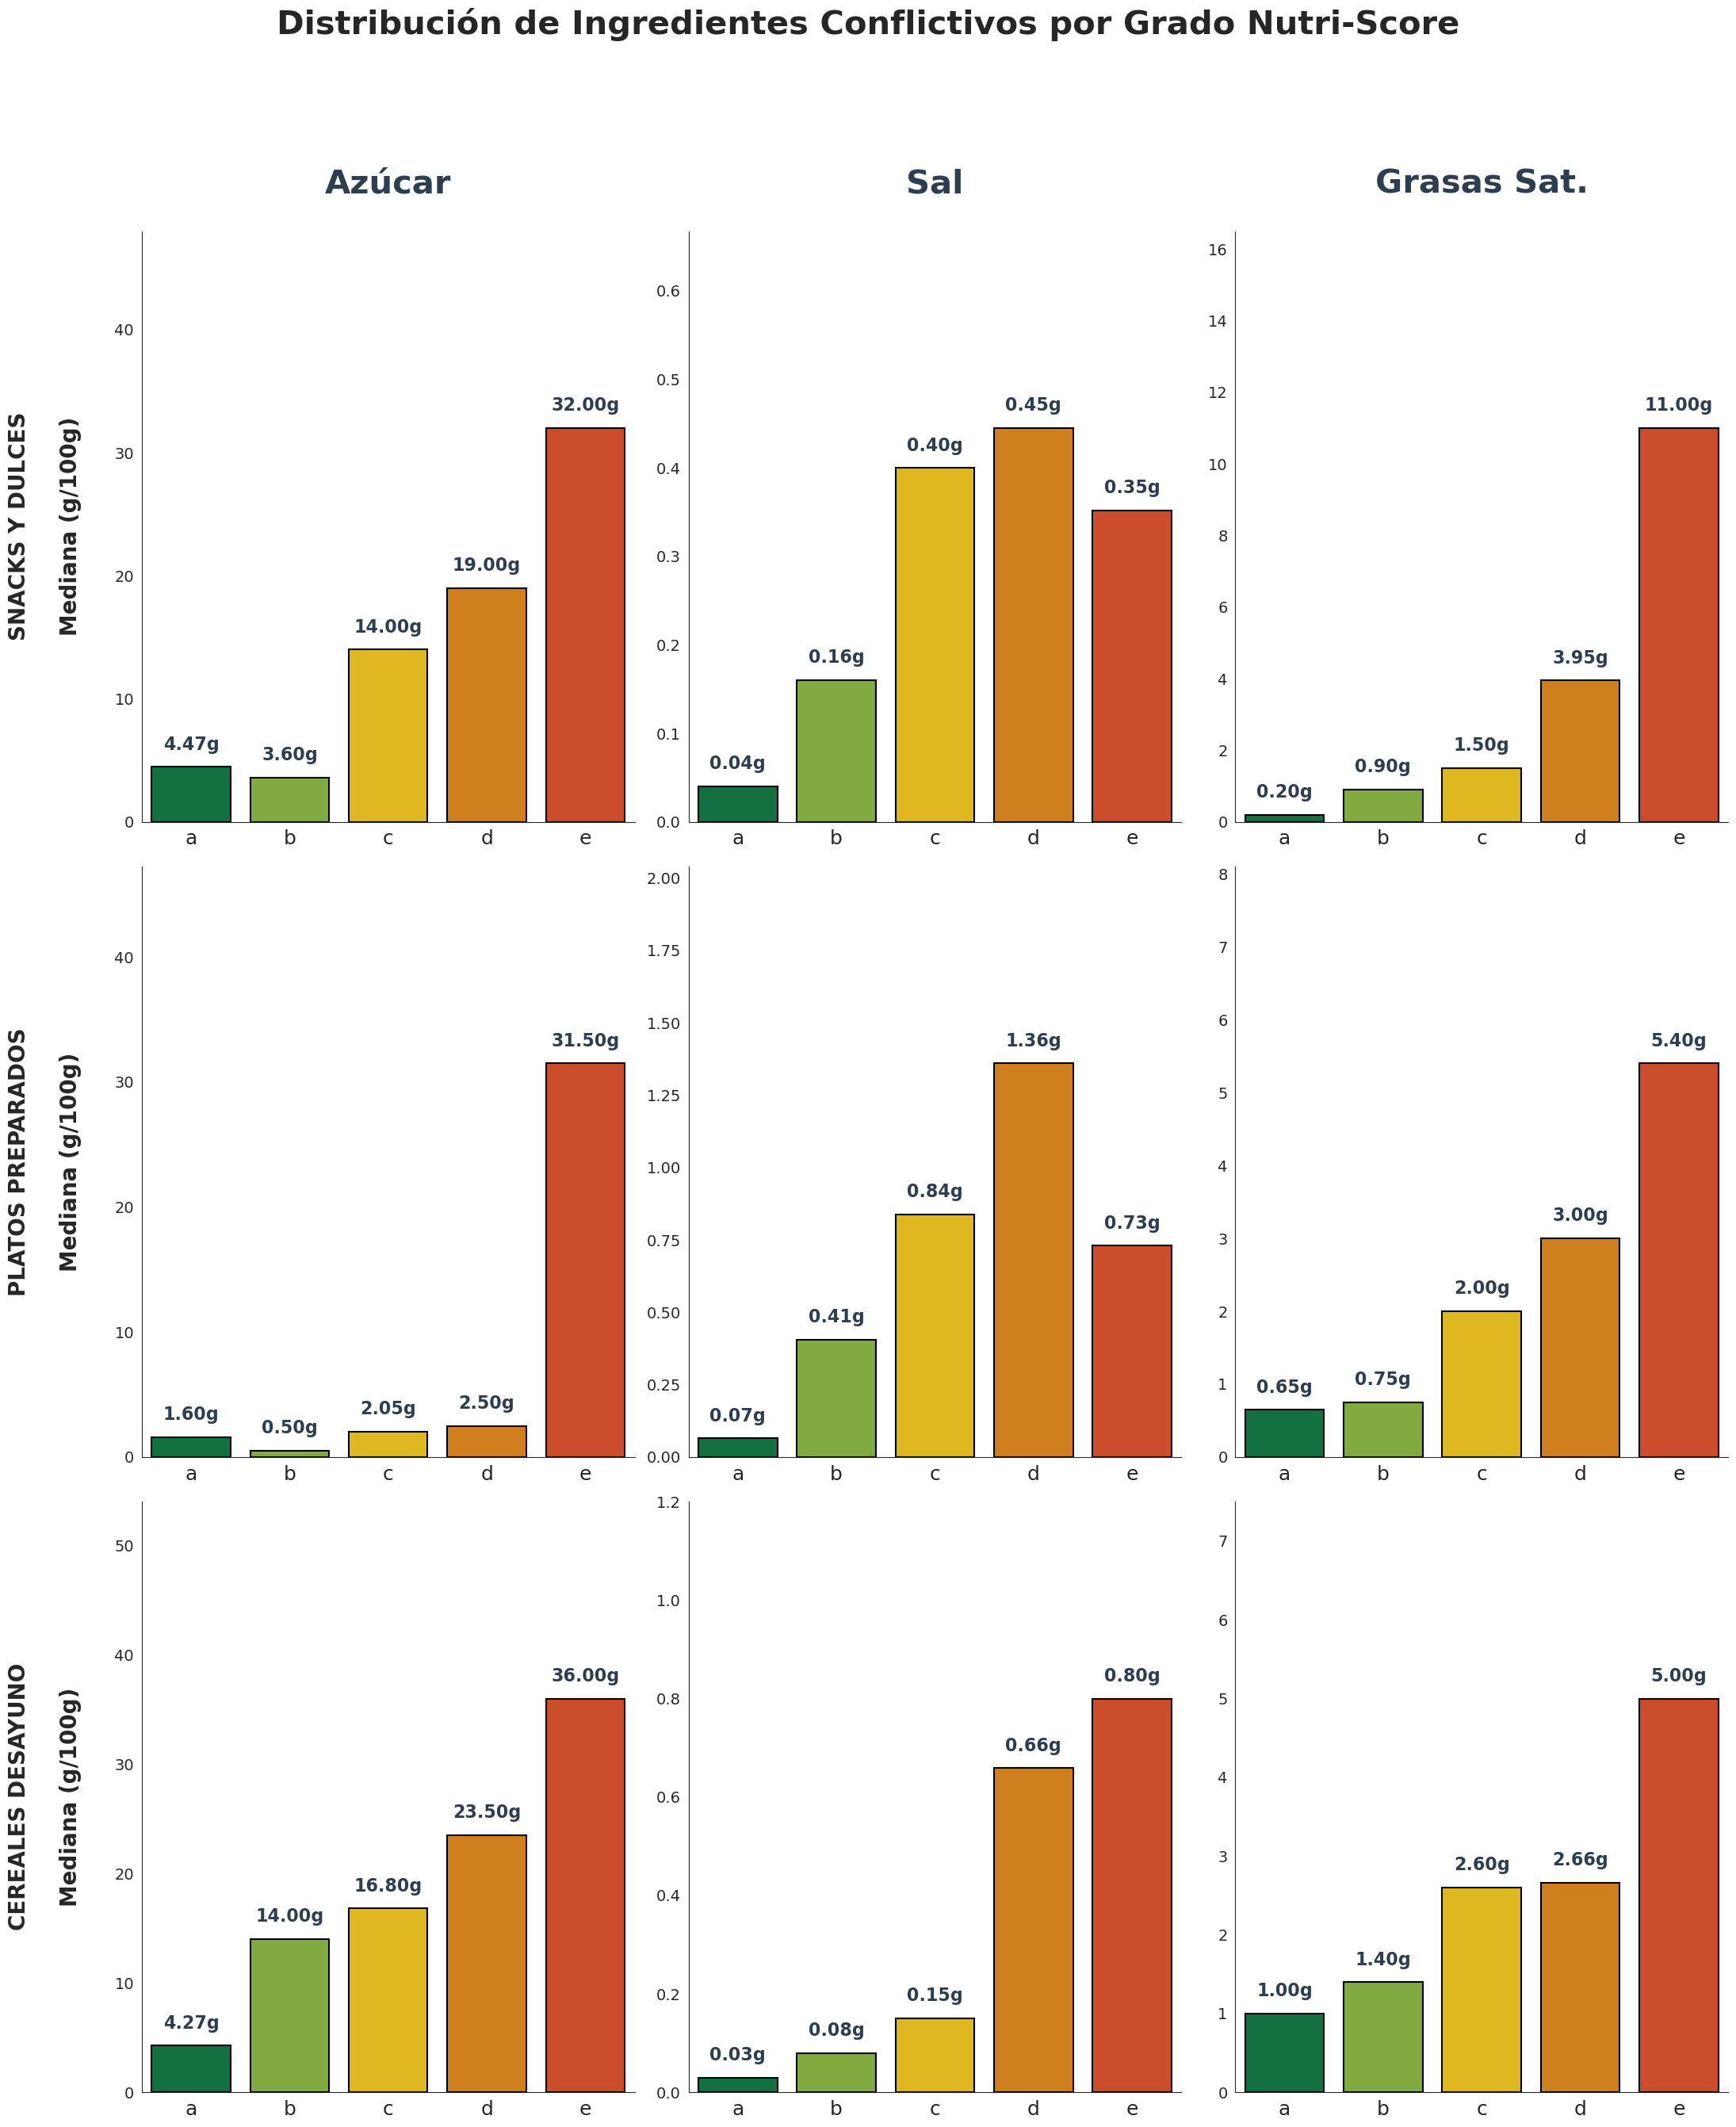

In [24]:
# --- MATRIZ NUTRICIONAL 3x3 CON TRADUCCIÓN AUTOMÁTICA ---

# 1. Configuración de categorías e IDs (mantenemos los originales para filtrar el DataFrame)
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals']
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
unidades = ['g', 'g', 'g']
titulos_nutri = ['Azúcar', 'Sal', 'Grasas Sat.']

# --- DICCIONARIO DE TRADUCCIÓN  ---
traduccion_cat = {
    "beverage": "Bebidas y Refrescos",
    "dairy_eggs": "Lácteos",
    "meat_fish": "Carnes y Pescados",
    "fats_sauces": "Grasas y Salsas",
    "snacks_sweets": "Snacks y Dulces",
    "plant_based": "Frutas y Verduras",
    "plant_based_protein": "Análogos Cárnicos Vegetales",
    "plant_based_milks": "Análogos Lácteos Vegetales",
    "bread_and_grains": "Pan y Cereales",
    "ready_to_eat": "Platos Preparados",
    "breakfast_cereals": "Cereales Desayuno",
    "seeds_nuts": "Frutos Secos y Cremas"
}

# Paleta oficial de Nutri-Score
nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}

# 2. Filtramos el dataset
df_plot = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 3. Configuración de la matriz 3x3
sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(22, 26))
order = ['a', 'b', 'c', 'd', 'e']

# 4. Generación de la matriz con traducción
for row, cat_id in enumerate(top_categories):
    # EXTRAEMOS LA TRADUCCIÓN: Si no existe en el diccionario, usa el ID original
    nombre_es = traduccion_cat.get(cat_id, cat_id).upper()
    
    for col, nutri in enumerate(nutrientes):
        ax = axes[row, col]
        
        # Filtramos datos y calculamos mediana
        data_subset = df_plot[df_plot['category_unified'] == cat_id]
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette=nutri_palette, hue='nutriscore_grade', 
            legend=False, edgecolor='black', linewidth=1.5
        )
        
        # Anotaciones de los valores (Grandes y claros)
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val >= 0:
                ax.annotate(f'{val:.2f}{unidades[col]}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='bottom', 
                            xytext=(0, 12), textcoords='offset points', 
                            fontsize=16, fontweight='bold', color='#2c3e50')

        # Títulos de columna (Solo en la fila superior)
        if row == 0:
            ax.set_title(f"{titulos_nutri[col]}", fontsize=30, fontweight='bold', pad=35, color='#2c3e50')
            
        # Etiquetas de fila traducidas (Solo en la columna de la izquierda)
        if col == 0:
            ax.set_ylabel(f"{nombre_es}\n\nMediana (g/100g)", fontsize=20, fontweight='bold', labelpad=30)
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=14)
        
        # Ajuste de límites para que el texto no choque arriba
        max_val = medianas_subset[nutri].max()
        ax.set_ylim(0, max_val * 1.5 if max_val > 0 else 5)
            
        sns.despine(ax=ax)

# Título principal y ajustes finales
plt.suptitle("Distribución de Ingredientes Conflictivos por Grado Nutri-Score", 
             fontsize=30, fontweight='bold', y=1.03)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()

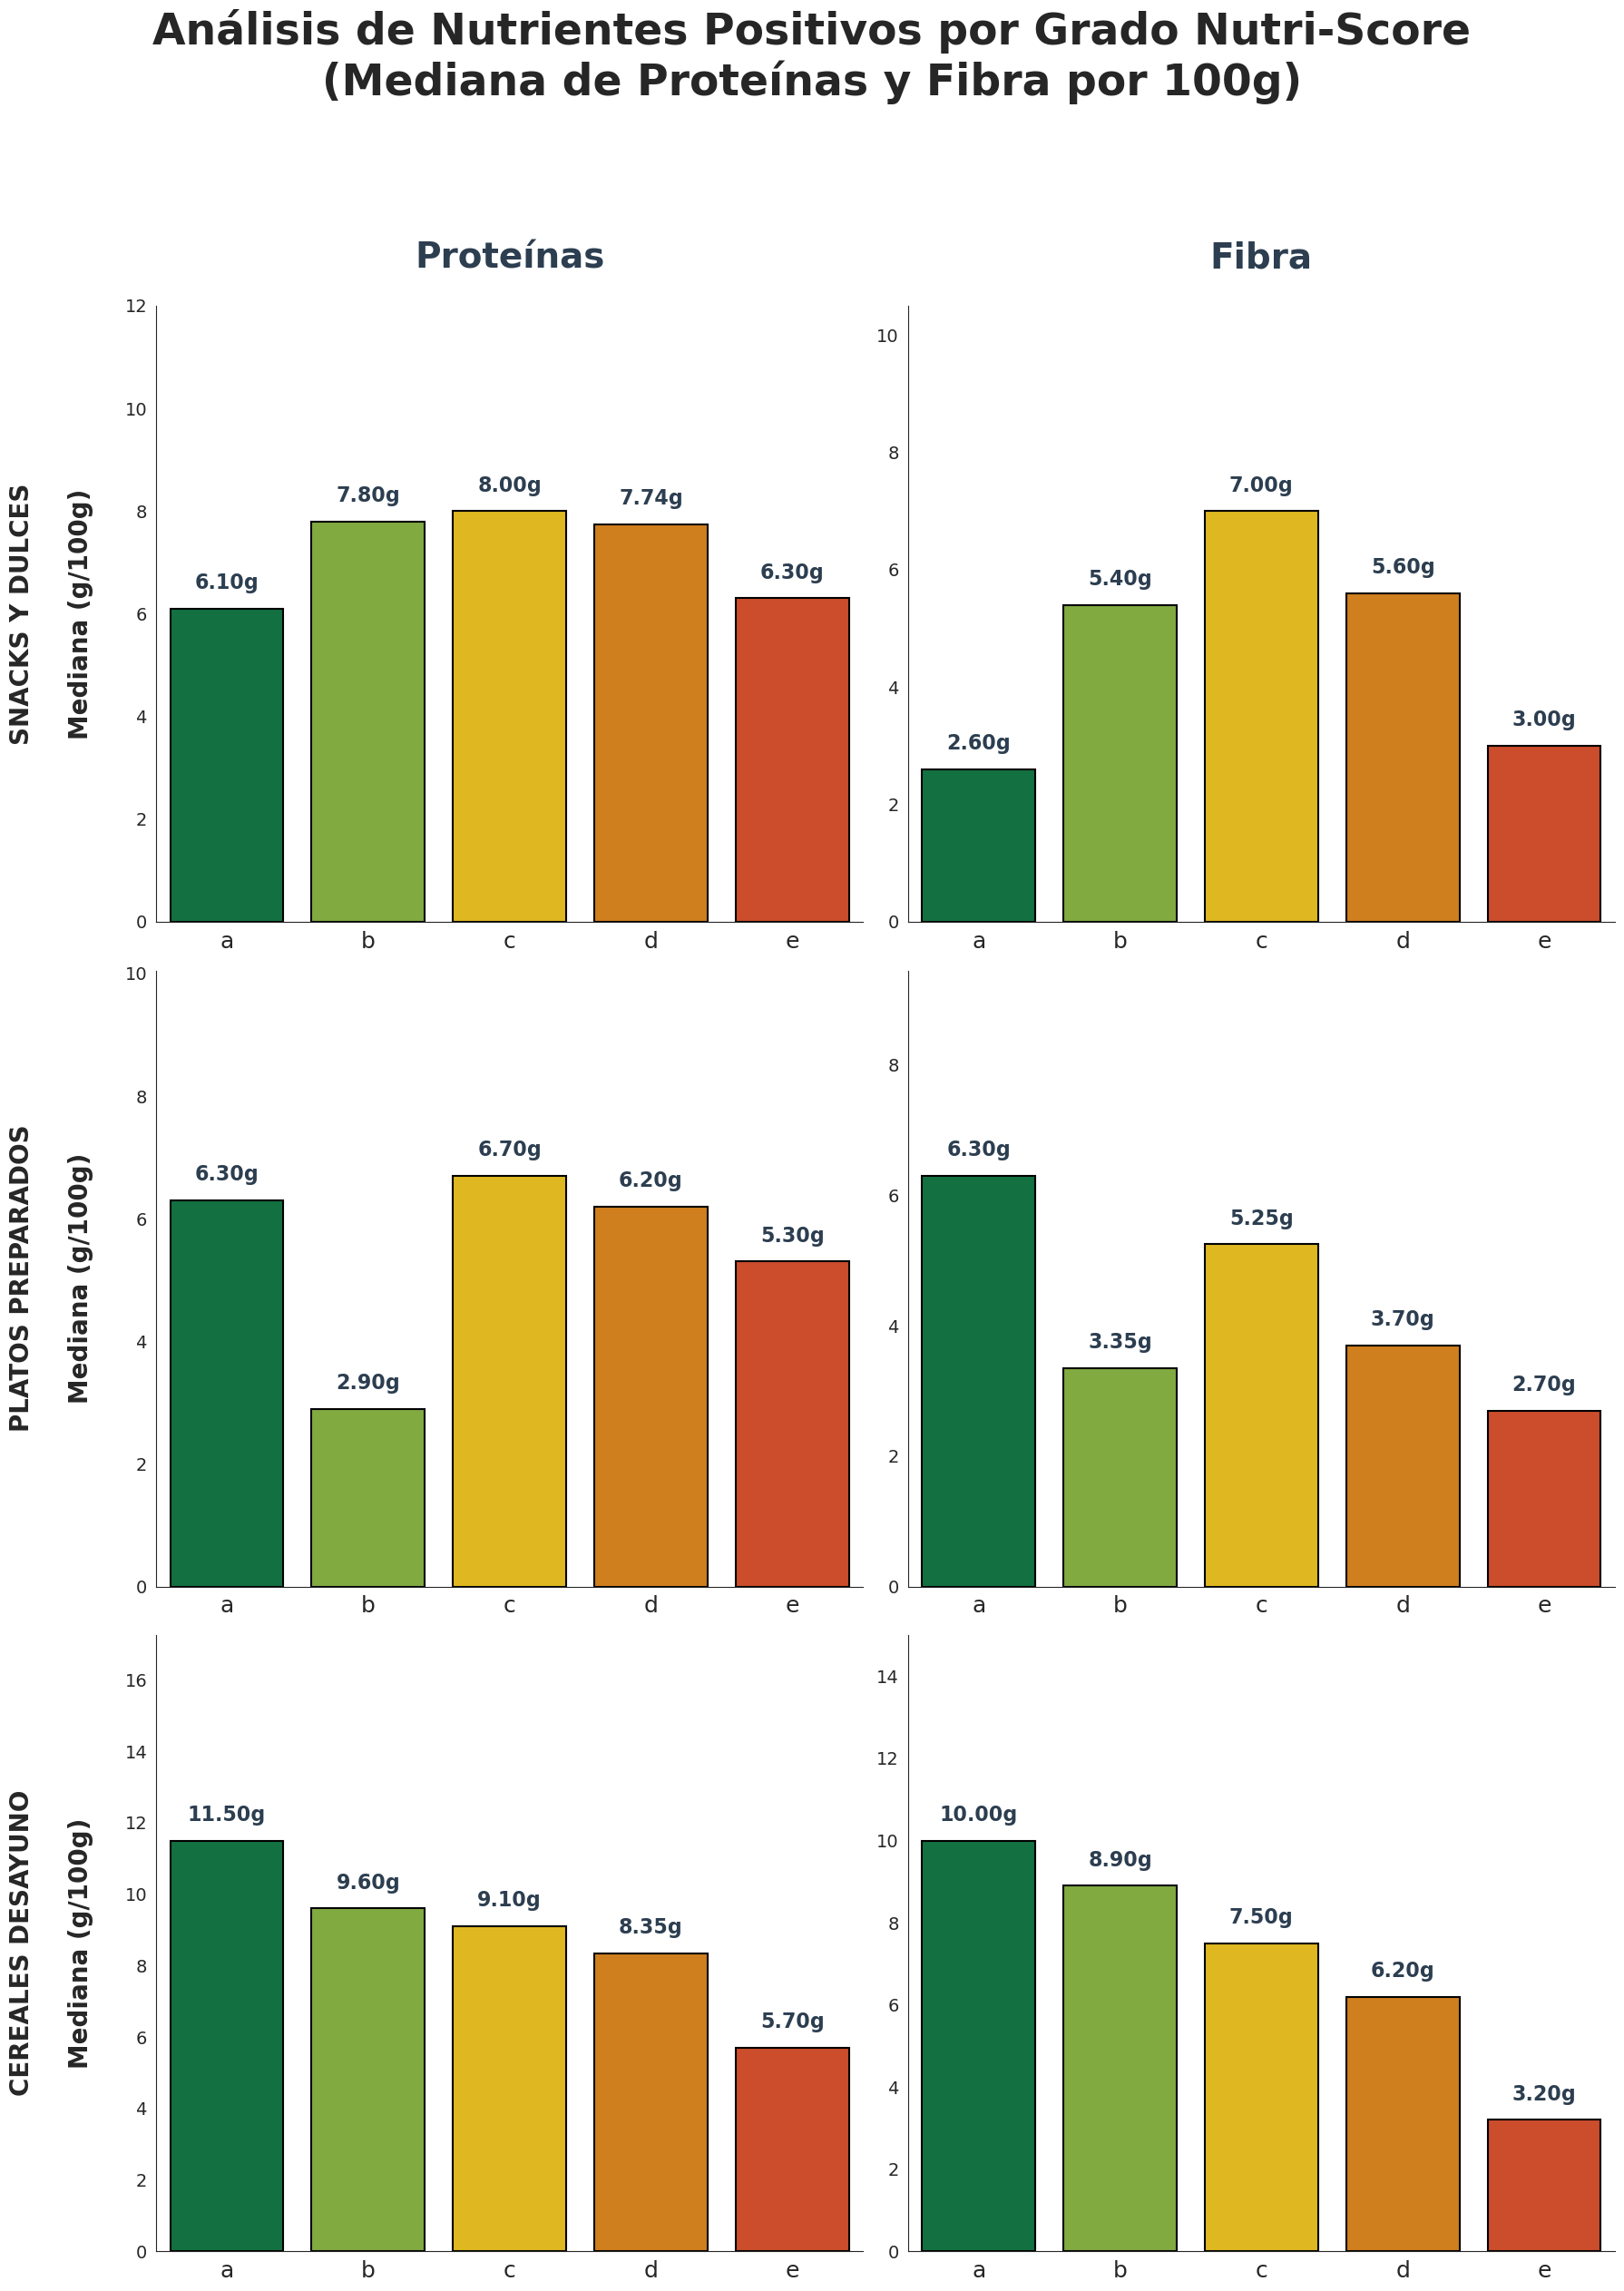

In [25]:
# --- MATRIZ DE NUTRIENTES POSITIVOS (ESTÉTICA MAXIMIZADA Y TRADUCIDA) ---

# 1. Configuración de categorías y nutrientes
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals']
nutrientes_pos = ['proteins_100g', 'fiber_100g']
titulos_pos = ['Proteínas', 'Fibra']

# Paleta oficial Nutri-Score
nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}

# Filtramos el dataset
df_pos = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 2. Configuración de la matriz 3x2
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(18, 24))
order = ['a', 'b', 'c', 'd', 'e']

# 3. Bucle para generar la matriz con traducción
for row, cat_id in enumerate(top_categories):
    # Traducimos usando el diccionario previo
    nombre_es = traduccion_cat.get(cat_id, cat_id).upper()
    
    for col, nutri in enumerate(nutrientes_pos):
        ax = axes[row, col]
        
        # Filtramos datos y calculamos la MEDIANA 
        data_subset = df_pos[df_pos['category_unified'] == cat_id]
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette=nutri_palette, hue='nutriscore_grade', 
            legend=False, edgecolor='black', linewidth=1.5
        )
        
        # Anotaciones con 2 decimales y fuente grande
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val >= 0:
                ax.annotate(f'{val:.2f}g', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='bottom', 
                            xytext=(0, 12), textcoords='offset points', 
                            fontsize=16, fontweight='bold', color='#2c3e50')

        # Títulos de columna (Solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_pos[col]}", fontsize=28, fontweight='bold', pad=30, color='#2c3e50')
            
        # Etiquetas de fila traducidas (Solo primera columna)
        if col == 0:
            ax.set_ylabel(f"{nombre_es}\n\nMediana (g/100g)", fontsize=20, fontweight='bold', labelpad=25)
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=14)
        
        # Ajuste de escala para que las etiquetas no se corten
        max_val = medianas_subset[nutri].max()
        ax.set_ylim(0, max_val * 1.5 if max_val > 0 else 2)
            
        sns.despine(ax=ax)

# Título general imponente
plt.suptitle("Análisis de Nutrientes Positivos por Grado Nutri-Score\n(Mediana de Proteínas y Fibra por 100g)", 
             fontsize=34, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

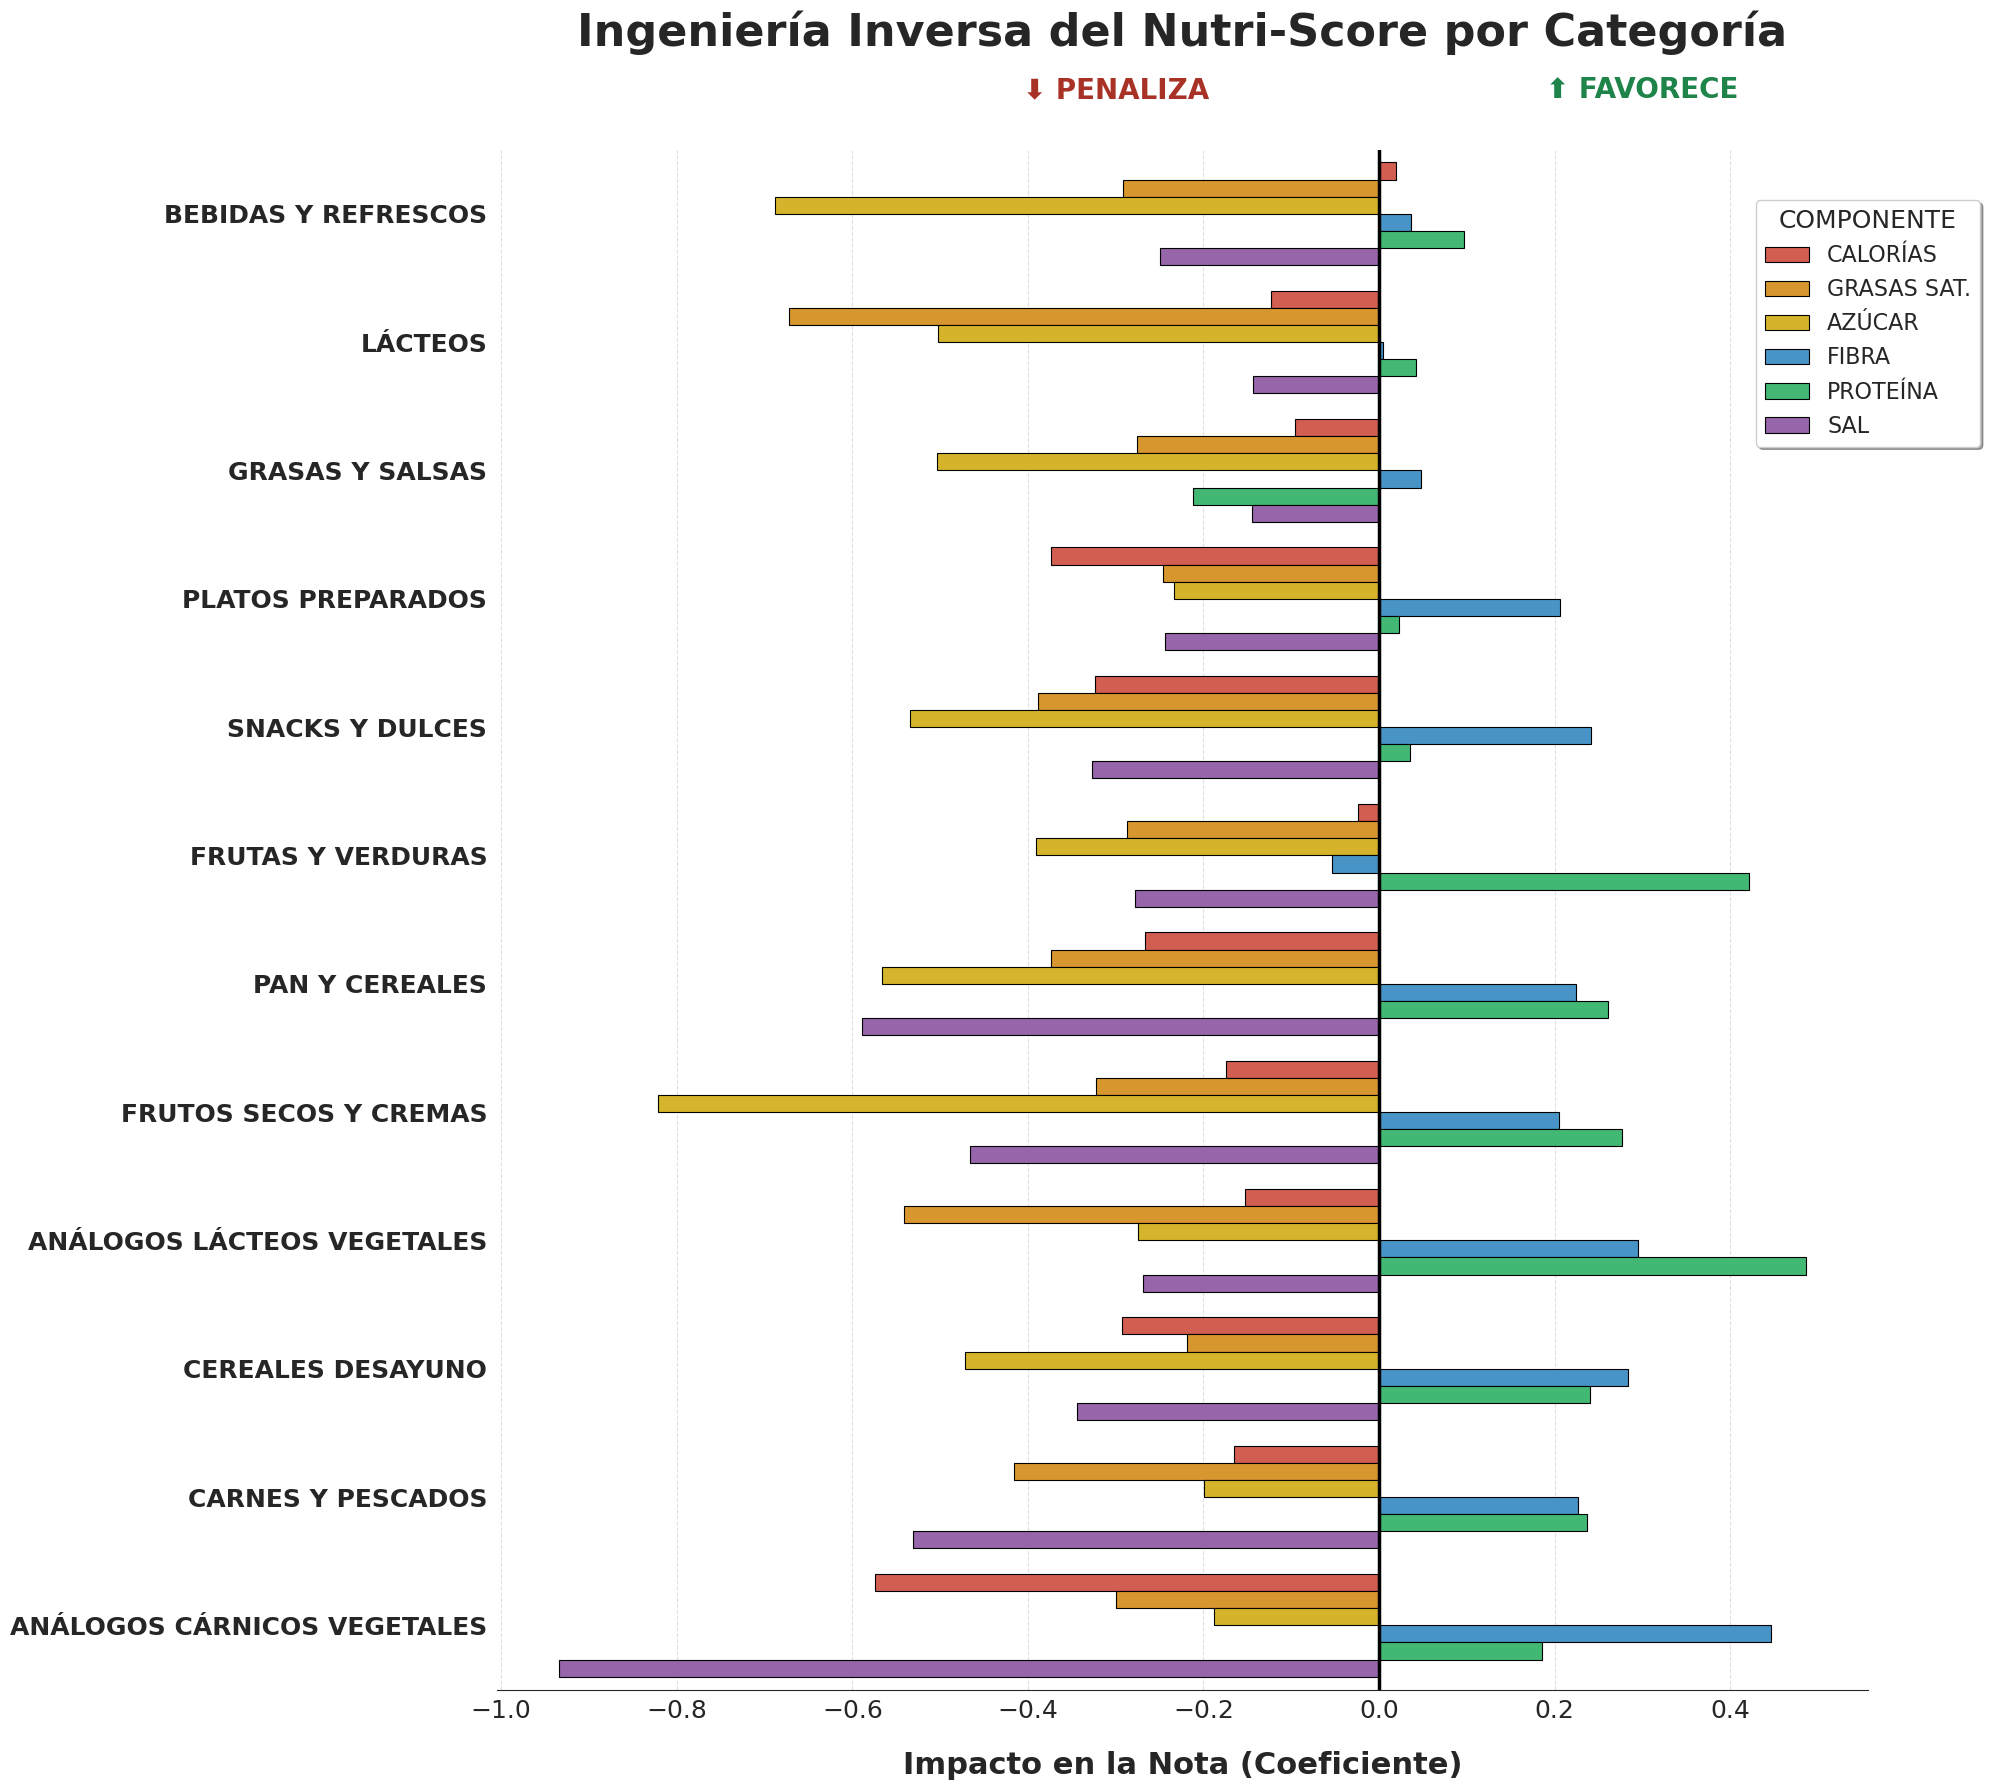

In [26]:
# --- PROCESAMIENTO DE DATOS ---
df_reg = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
# Invertimos la escala: a=5 (mejor), e=1 (peor) para que los coeficientes positivos "ayuden" a la nota
df_reg['nutri_numeric'] = df_reg['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

nutrientes = ['energy-kcal_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']
results = []

# --- 2. MOTOR DE REGRESIÓN ---
for cat in df_reg['category_unified'].unique():
    cat_data = df_reg[df_reg['category_unified'] == cat].dropna(subset=nutrientes + ['nutri_numeric'])
    
    # Solo categorías con suficiente volumen estadístico
    if len(cat_data) > 20:
        X = cat_data[nutrientes]
        y = cat_data['nutri_numeric']
        
        # Estandarización: permite comparar kcal con gramos de sal de forma justa
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        model = LinearRegression()
        model.fit(X_scaled, y)
        
        # Obtenemos el nombre traducido usando tu diccionario
        cat_es = traduccion_cat.get(cat, cat).upper()
        
        for i, nutri in enumerate(nutrientes):
            # Limpiamos nombres de nutrientes para la leyenda
            nutri_label = nutri.replace('-kcal_100g', '').replace('_100g', '').replace('saturated-fat', 'Grasas Sat.').replace('sugars', 'Azúcar').replace('fiber', 'Fibra').replace('proteins', 'Proteína').replace('salt', 'Sal').replace('energy', 'Calorías').upper()
            
            results.append({
                'category': cat_es,
                'nutrient': nutri_label,
                'coefficient': model.coef_[i]
            })

df_results = pd.DataFrame(results)

# --- 3. VISUALIZACIÓN PROFESIONAL ---
plt.figure(figsize=(20, 18))
sns.set_style("white")

# Colores diferenciados para cada componente
colores = ["#e74c3c", "#f39c12", "#f1c40f", "#3498db", "#2ecc71", "#9b59b6"]

ax = sns.barplot(
    data=df_results, 
    x='coefficient', 
    y='category', 
    hue='nutrient', 
    palette=colores,
    edgecolor='black',
    linewidth=0.8
)

# Estética de ejes
plt.xticks(fontsize=18)
plt.yticks(fontsize=18, fontweight='bold')

# Línea de equilibrio (Cero)
plt.axvline(0, color='black', linestyle='-', linewidth=2.5)

# Títulos y etiquetas (Maximizadas)
plt.title("Ingeniería Inversa del Nutri-Score por Categoría", fontsize=32, pad=75, fontweight='bold')
plt.xlabel("Impacto en la Nota (Coeficiente)", fontsize=22, fontweight='bold', labelpad=20)
plt.ylabel("", fontsize=20) # Quitamos 'Categoría' para dar aire

# Leyenda profesional arriba
plt.legend(
    title="COMPONENTE", 
    title_fontsize=18, 
    fontsize=16, 
    loc='lower center', 
    bbox_to_anchor=(1, 0.8), 
    ncol=1, 
    frameon=True,
    shadow=True
)

# Anotaciones de guía (Interpretación del modelo)
plt.text(0.3, -0.9, "⬆️ FAVORECE", color='#1e8449', fontweight='bold', ha='center', fontsize=20, bbox=dict(facecolor='white', alpha=0.8))
plt.text(-0.3, -0.9, "⬇️ PENALIZA", color='#a93226', fontweight='bold', ha='center', fontsize=20, bbox=dict(facecolor='white', alpha=0.8))

# Ajuste de márgenes y cuadrícula sutil
plt.grid(axis='x', linestyle='--', alpha=0.6)
sns.despine(left=True)
plt.tight_layout()

# --- 4. GUARDAR Y MOSTRAR ---
plt.savefig('../images/01_h01/1.4_regresion.png', bbox_inches='tight', dpi=300)
plt.show()

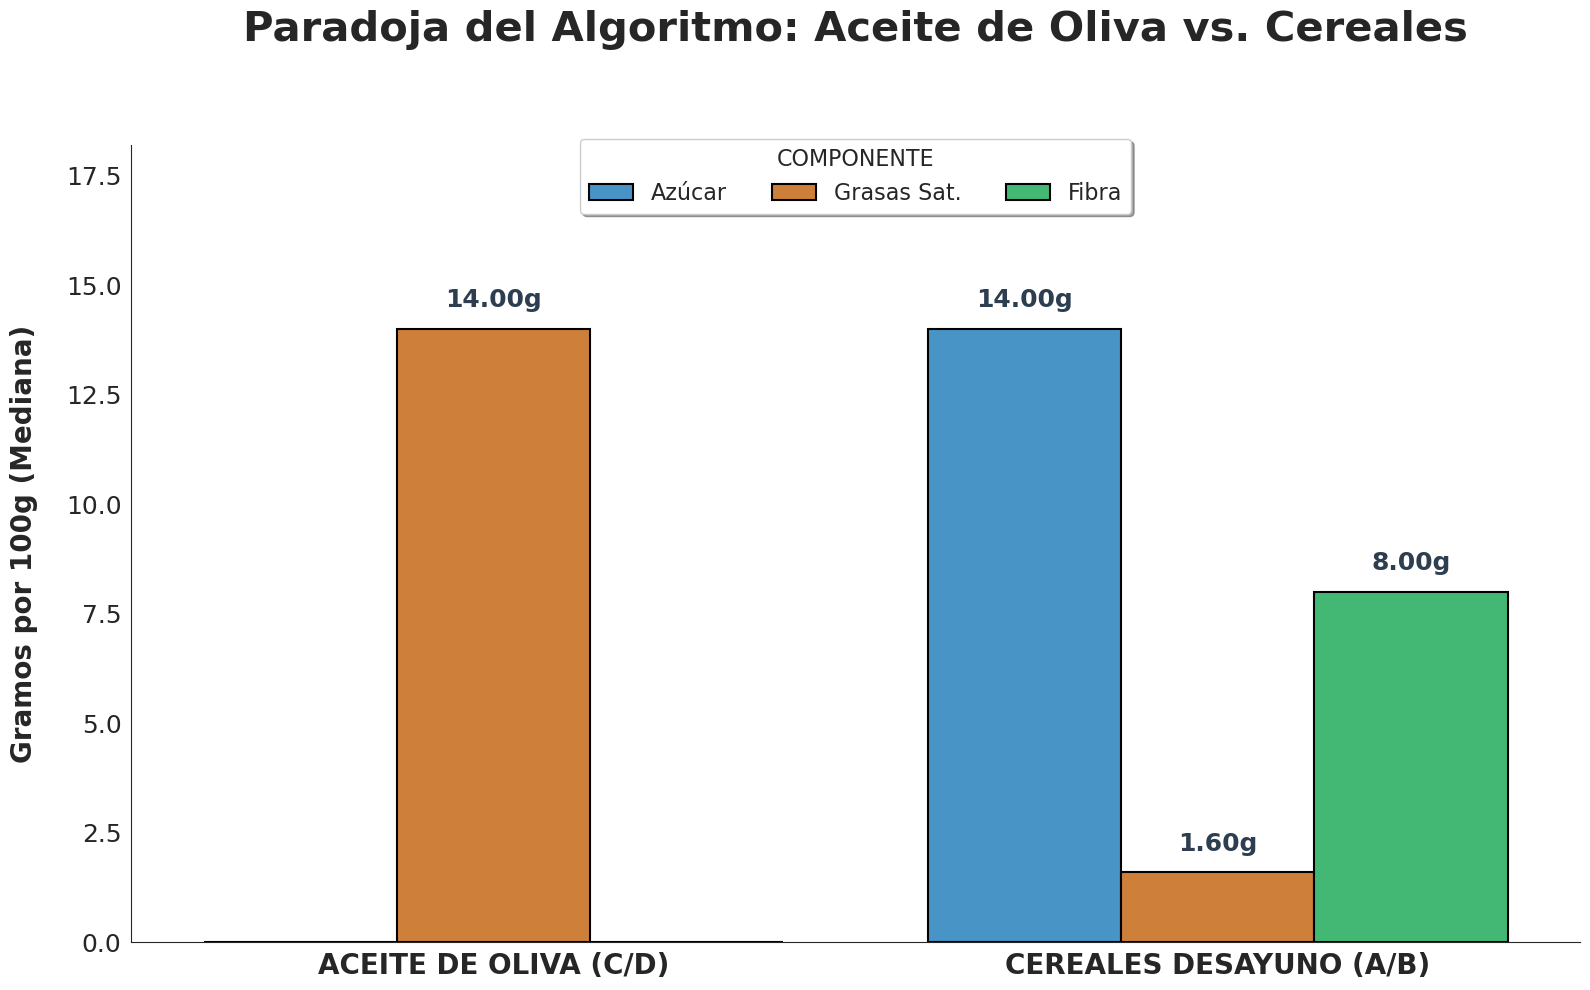

In [27]:
# --- COMPARATIVA DE PARADOJA: ACEITE VS CEREALES ---

# 1. Filtrado y etiquetado
aceites = foods[
    (foods['product_name'].str.contains('olive oil|aceite de oliva|huile d\'olive', case=False, na=False))
].copy()
aceites['group_label'] = 'ACEITE DE OLIVA (C/D)'

cereales = foods[
    (foods['category_unified'] == 'breakfast_cereals')
].copy()
cereales['group_label'] = 'CEREALES DESAYUNO (A/B)'

# Combinamos y preparamos
df_comp = pd.concat([aceites, cereales])
nutri_cols = {'sugars_100g': 'Azúcar', 'saturated-fat_100g': 'Grasas Sat.', 'fiber_100g': 'Fibra'}

# Calculamos medianas y transformamos
df_medians = df_comp.groupby('group_label')[list(nutri_cols.keys())].median().reset_index()
df_melted = df_medians.melt(id_vars='group_label', var_name='Nutriente', value_name='g_100g')
df_melted['Nutriente'] = df_melted['Nutriente'].map(nutri_cols)

# 2. Visualización
plt.figure(figsize=(16, 10))
sns.set_style("white") # Fondo limpio

paleta_nutri = {
    'Azúcar': '#3498db', 
    'Grasas Sat.': '#e67e22', 
    'Fibra': '#2ecc71'
}

ax = sns.barplot(
    data=df_melted,
    x='group_label',
    y='g_100g',
    hue='Nutriente',
    palette=paleta_nutri,
    edgecolor='black',
    linewidth=1.5
)

# 3. Estética y Fuentes Maximizadas
plt.title("Paradoja del Algoritmo: Aceite de Oliva vs. Cereales", 
          fontsize=30, fontweight='bold', pad=75)

plt.ylabel("Gramos por 100g (Mediana)", fontsize=20, fontweight='bold', labelpad=20)
plt.xlabel("", fontsize=1) 

# Números de los ejes
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=18)

# Leyenda profesional arriba centrada
plt.legend(
    title="COMPONENTE", 
    title_fontsize=16, 
    fontsize=16, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.9), 
    ncol=3, 
    frameon=True,
    shadow=True
)

# 4. Anotaciones de valor (2 decimales)
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0.1:
        ax.annotate(f'{height:.2f}g', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 12), 
                    textcoords='offset points',
                    fontsize=18, fontweight='bold', color='#2c3e50')

# Ajuste final
plt.ylim(0, df_melted['g_100g'].max() * 1.3)
sns.despine()
plt.tight_layout()

# --- 5. GUARDAR ---
plt.savefig('../images/01_h01/1.5_critica_aceite_cereales.png', bbox_inches='tight', dpi=300)
plt.show()